<a href="https://colab.research.google.com/github/uk808382-dev/Artificial-intelligence-CSC-262/blob/main/UCS_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

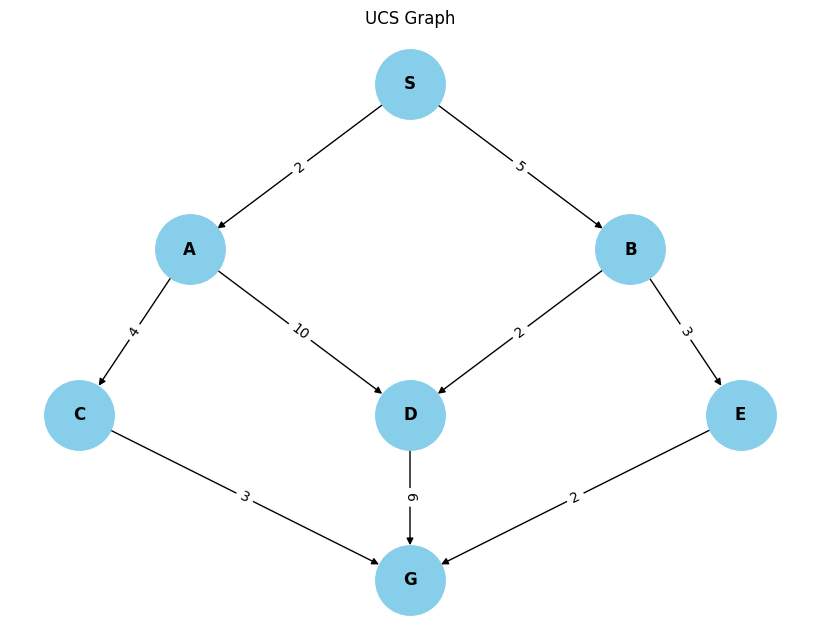

In [7]:
import heapq  # Used for priority queue (min-heap) → always picks lowest cost path first

# Graph representation using adjacency list
# Each node has a list of (neighbor, cost)
graph = {
    'S': [('A', 3), ('B', 2), ('C', 7)],
    'A': [('D', 8), ('E', 15)],
    'B': [('G', 20)],
    'C': [('G', 6)],
    'D': [],
    'E': [],
    'G': []
}

def uniform_cost_search(graph, start, goal):
    # Priority queue stores: (total_cost_so_far, current_node, path_taken)
    pq = []

    # Start from initial node with cost = 0
    heapq.heappush(pq, (0, start, [start]))

    # Keeps track of visited nodes to avoid re-processing same node
    visited = set()

    while pq:
        # Always expands the node with the LOWEST cost (core UCS idea)
        cost, node, path = heapq.heappop(pq)

        # If already visited, skip (prevents cycles and repeated work)
        if node in visited:
            continue

        # Mark node as visited once we expand it
        visited.add(node)

        # Goal test: if we reached destination, return result immediately
        if node == goal:
            return cost, path

        # Explore all neighbors of current node
        for neighbor, weight in graph[node]:

            # Only consider unvisited nodes
            if neighbor not in visited:

                # Add new path with updated cumulative cost
                heapq.heappush(
                    pq,
                    (cost + weight, neighbor, path + [neighbor])
                )

    # If goal is not reachable
    return None, None


# ---------------- RUN UCS ----------------

start = 'S'
goal = 'G'

cost, path = uniform_cost_search(graph, start, goal)

# Output result
print("Shortest Path:", " -> ".join(path))
print("Total Cost:", cost)

Shortest Path: S -> C -> G
Total Cost: 13
